In [ ]:
# analyse different systems with the same spectral radius and see how the vector orthogonal to the subspace develops

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sf_workingdir_lilly.dmlab.custom_esn_analysis import get_hidden_states_iso_feat, len_new_orth_vec, get_time_of_threshold_crossing

In [2]:
spec_rad = 1.4
time_steps = 70

Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
#trial=6
fixed_whh=True
fixed_wih=True


In [3]:
x_vals = np.arange(1,70)
#fig, ax = plt.subplots(10,5, figsize=(25,50), sharey=True, sharex=True)

orth_vec_lens = np.zeros((50, Hippo_n_feature, time_steps-1))

for t in range(50):
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, t, fixed_whh, fixed_wih, input_idx=i)
        try:
            len_orth_vectors = len_new_orth_vec(hs, time_steps)
            #ax[t//5, t%5].scatter(x_vals, len_orth_vectors, label=f'{i}', s=5)
            orth_vec_lens[t, i, :] = len_orth_vectors
        except Exception as e:
            print(f'Could not compute length of orthogonal vectors for trial {t} and input neuron {i}: {e}')
            pass
        #ax[t//5, t%5].set_title(f'{t}')

Could not compute length of orthogonal vectors for trial 24 and input neuron 5: linalg.svd: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 1).
Could not compute length of orthogonal vectors for trial 38 and input neuron 6: linalg.svd: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated singular values (error code: 1).


In [7]:
thresh_crossed = get_time_of_threshold_crossing(orth_vec_lens)
print(thresh_crossed)

[12. 28. 19. 27. 27. 19. 18. 18. 38. 27. 12. 26. 26. 14. 49. 26. 10. 25.
 24. 13. 13. 11. 29. 50. 15. 14. 10. 14. 17. 12. 13.  9. 11. 22.  8. 21.
 17. 11. 24. 49. 22. 20. 14. 18. 15. 41. 12. 15. 11. 20.]


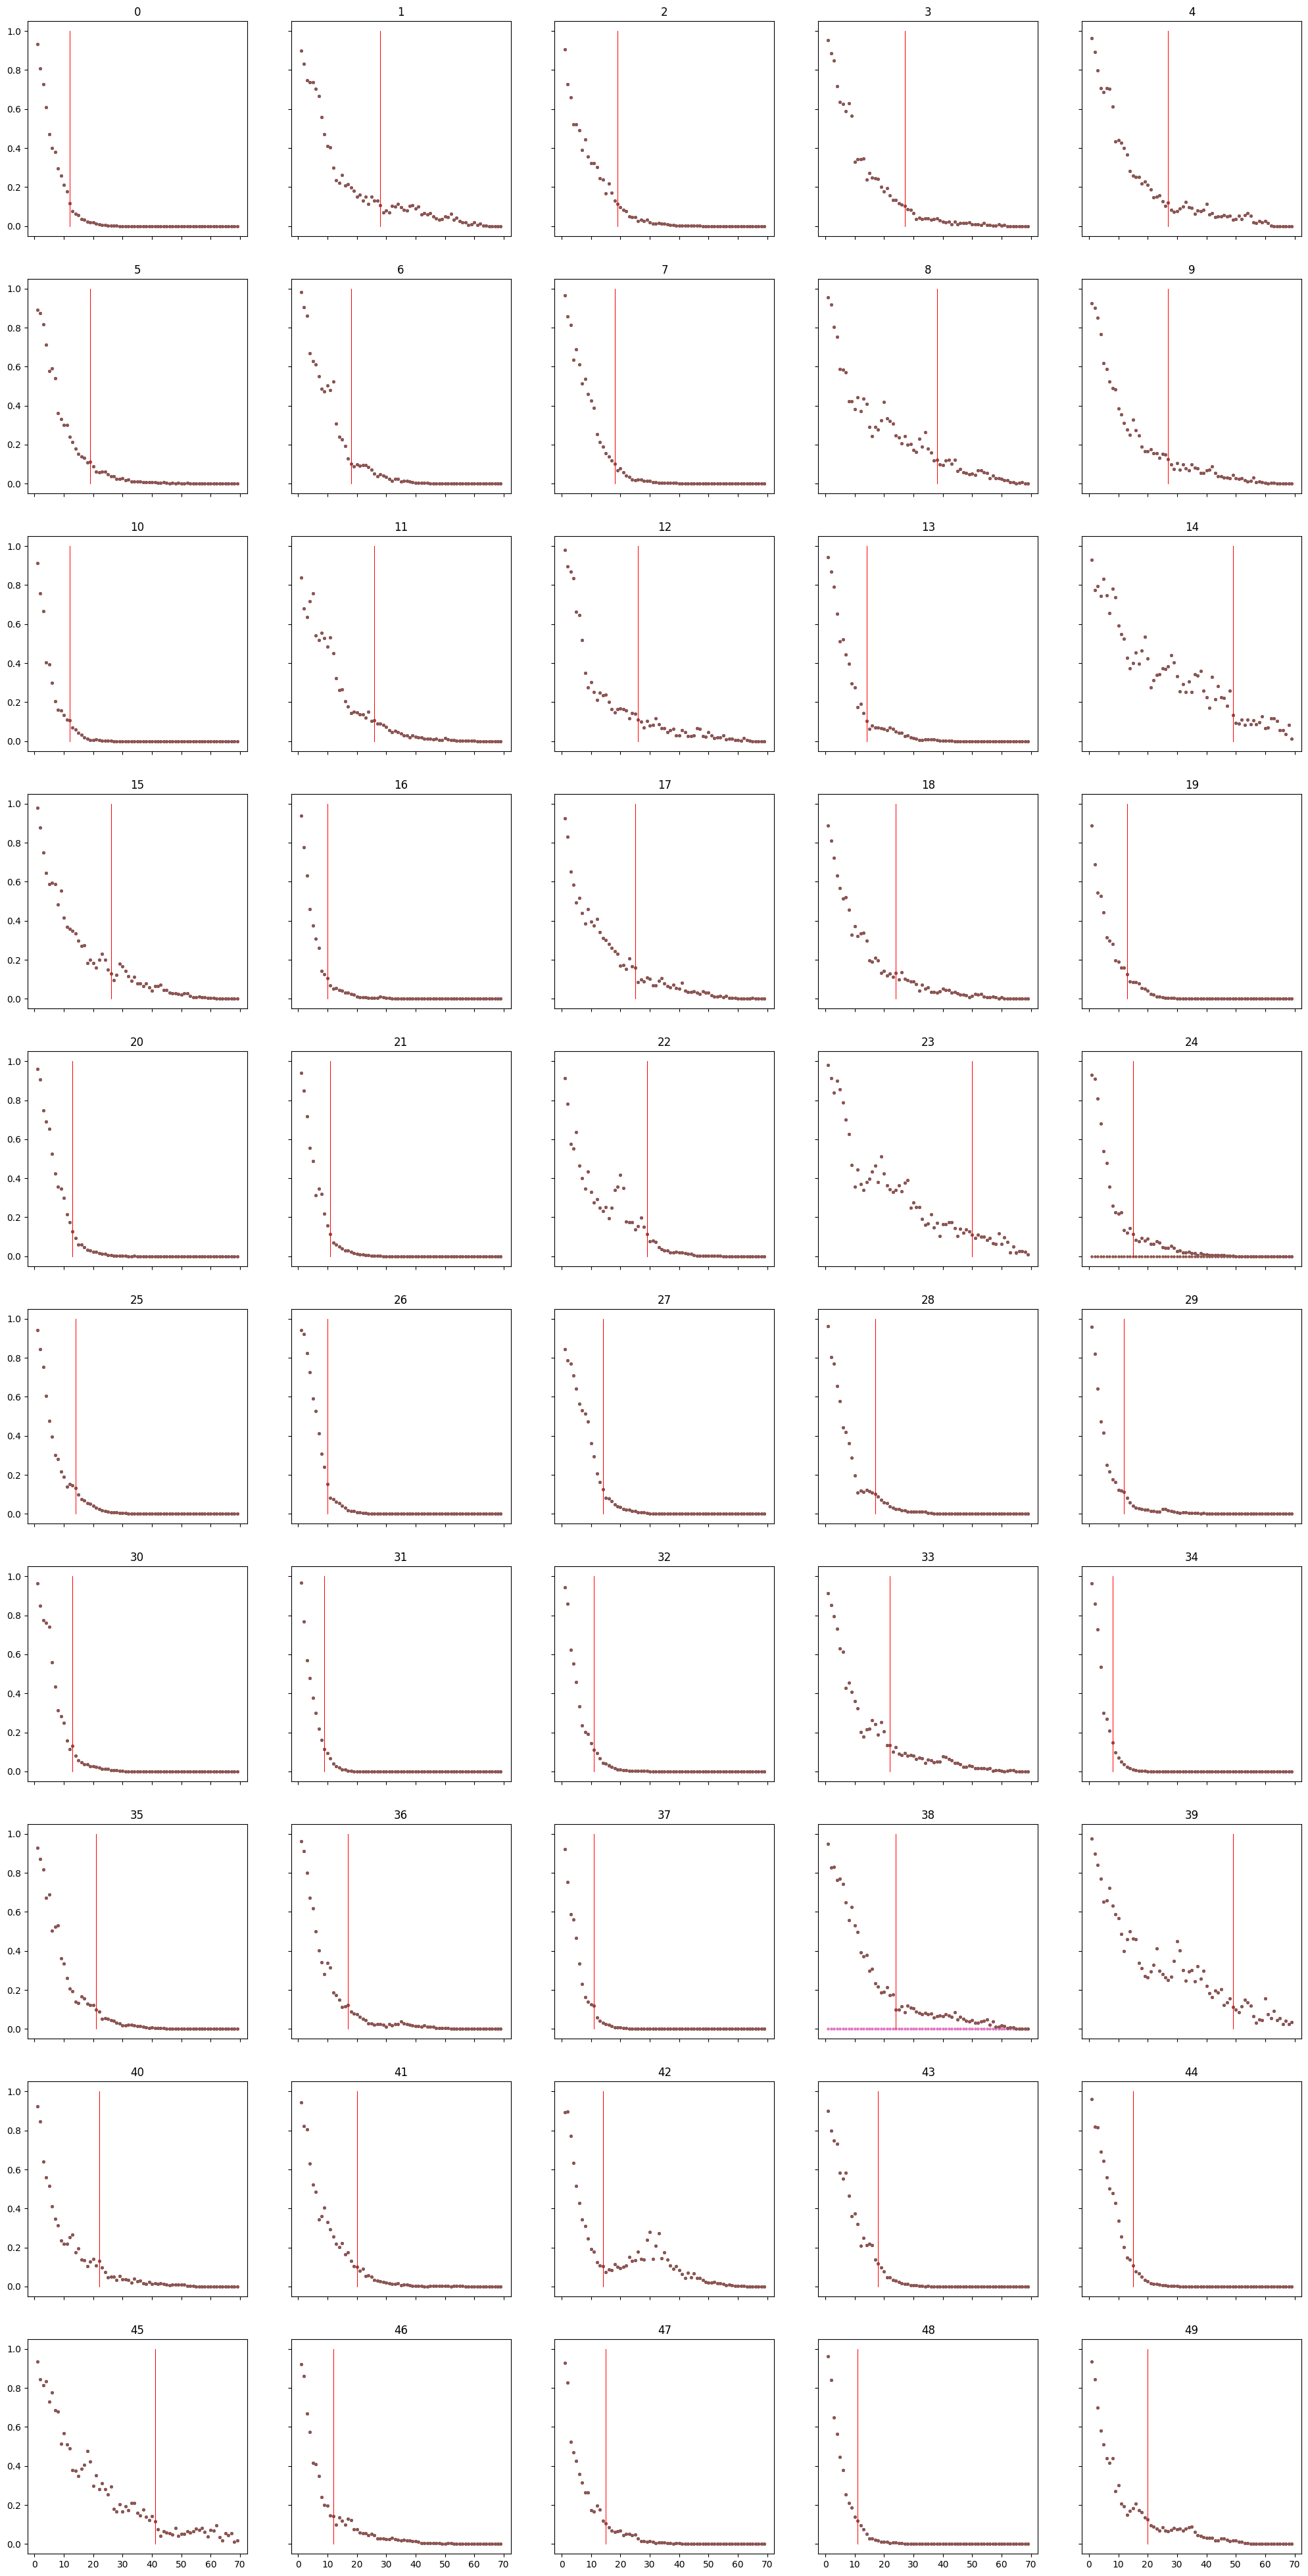

In [9]:
x_vals = np.arange(1,70)
fig, ax = plt.subplots(10,5, figsize=(25,50), sharey=True, sharex=True)
for t in range(50):
    for i in range(Hippo_n_feature):
        ax[t//5, t%5].scatter(x_vals, orth_vec_lens[t, i, :], label=f'{i}', s=5)
        ax[t//5, t%5].set_title(f'{t}')
        ax[t//5, t%5].vlines(thresh_crossed[t], ymin=0, ymax=1, colors='r', linewidths=0.5)

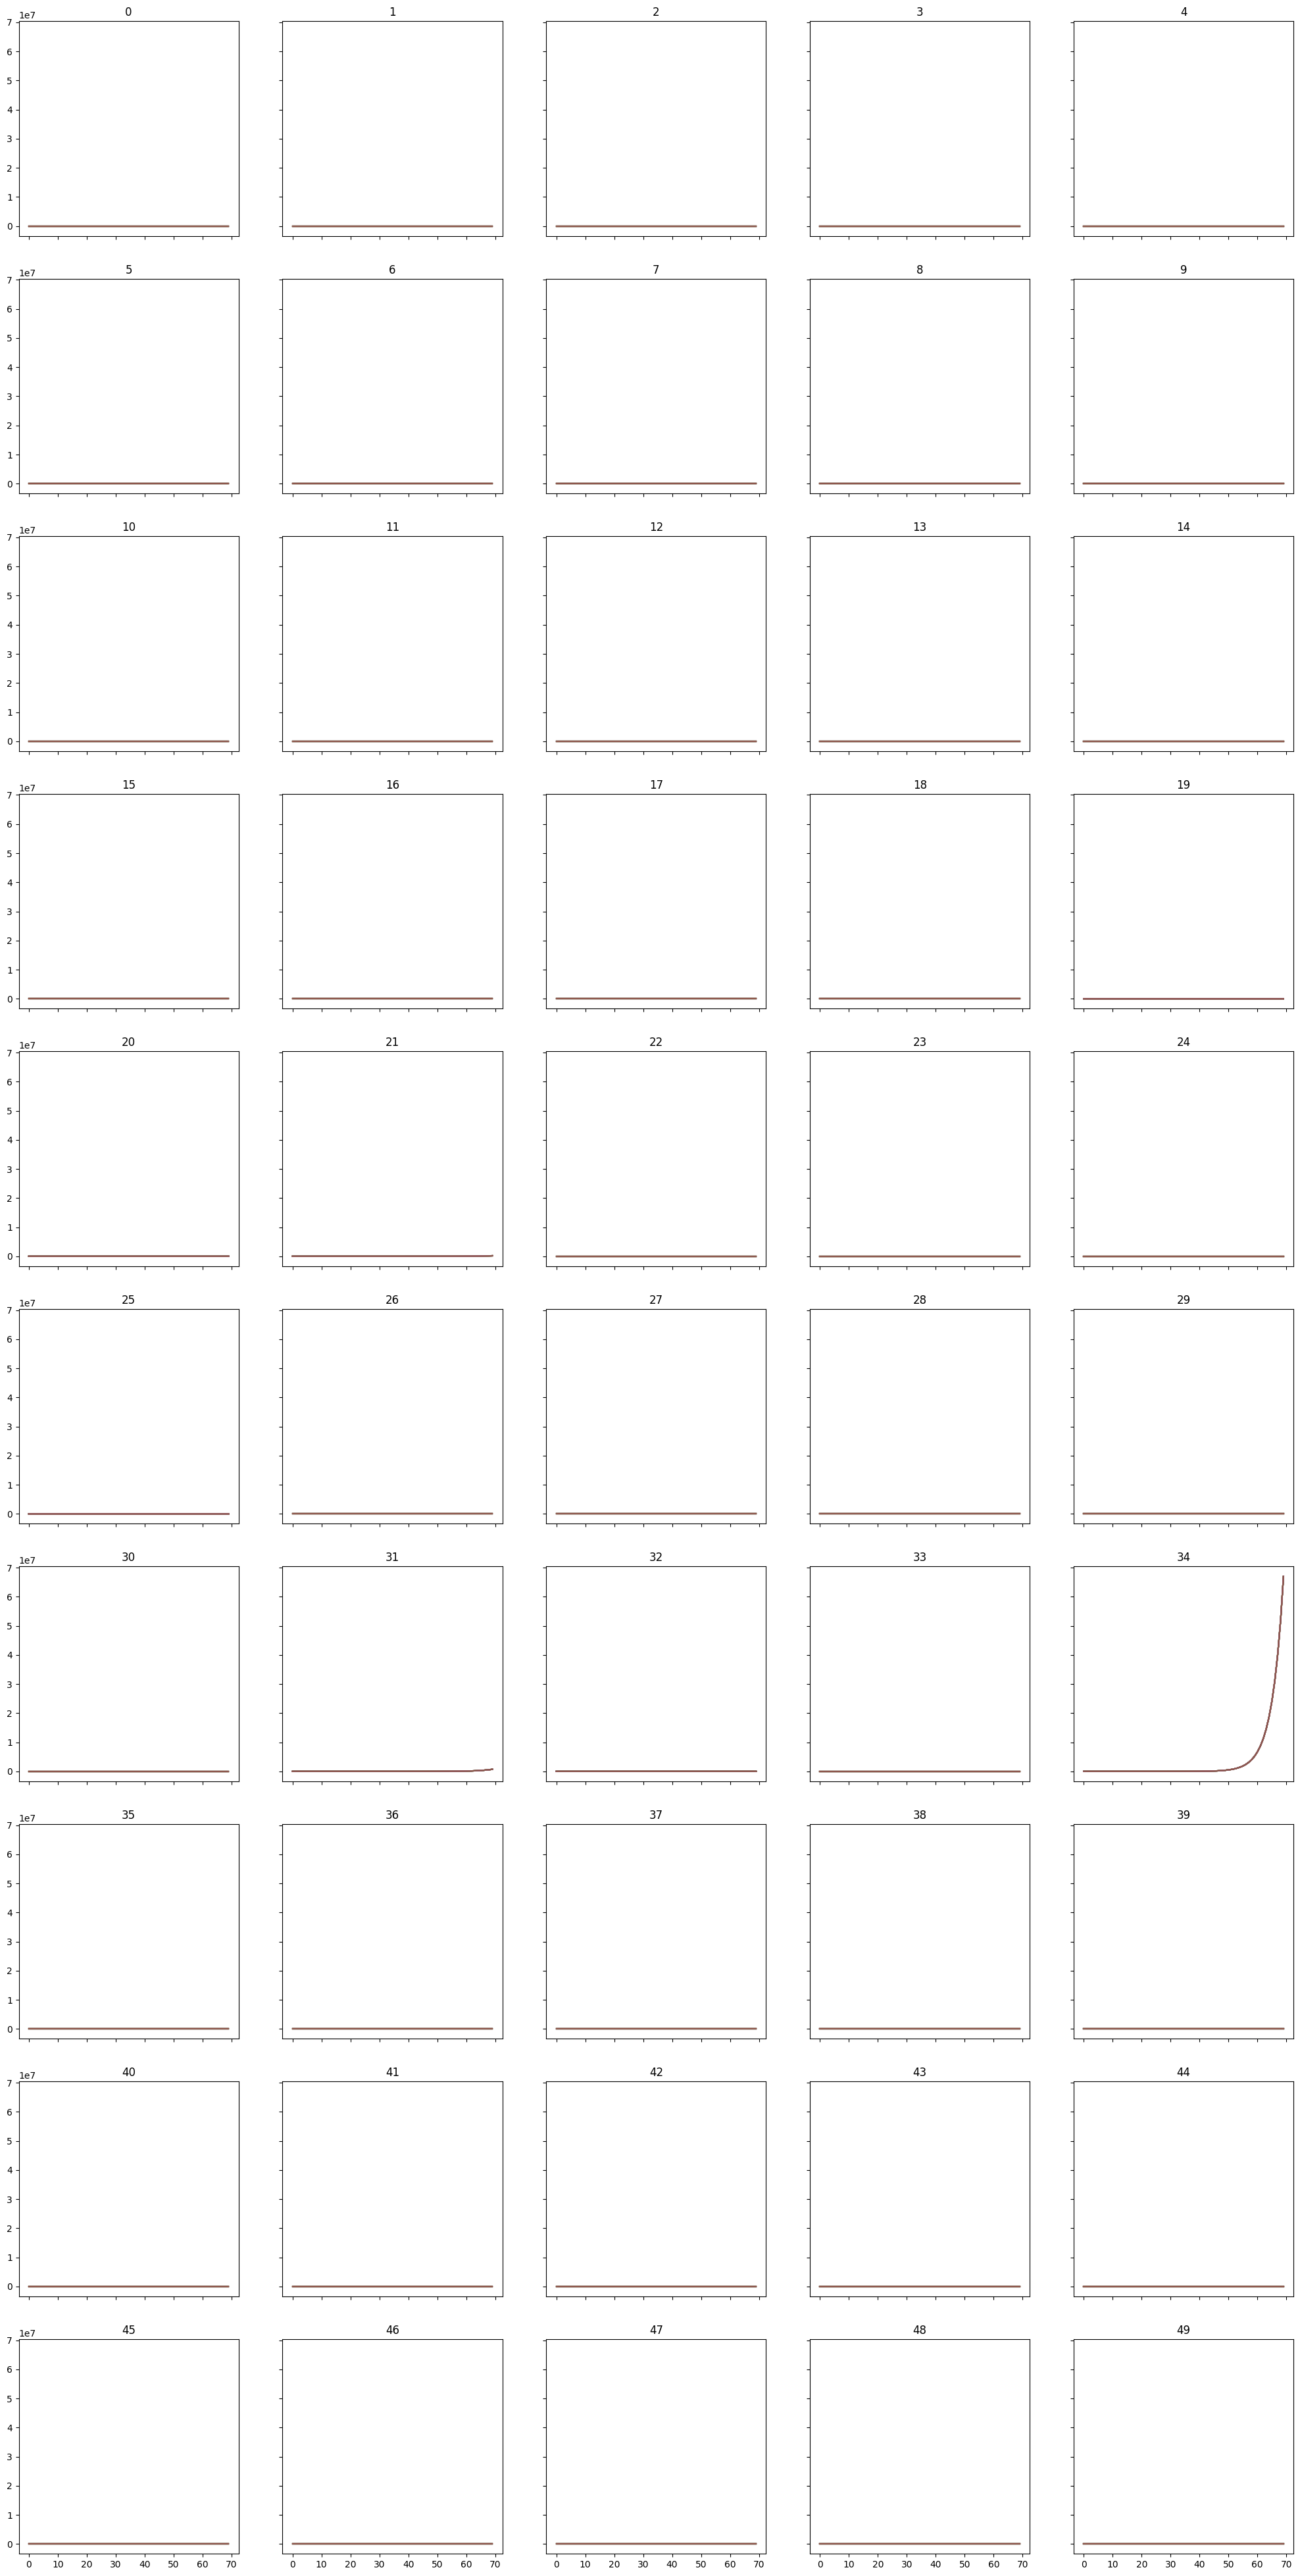

In [ ]:
for t in range(20):
    # create a (input_index, time_steps) matrix for each spectral radius - values in the matrix are the norms at this input index at that tiem - and create a plot where the norms are plotted against the time
    #neuron_norms = np.zeros((Hippo_n_feature,time_steps))
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1,5, figsize=(23,5))
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, t, fixed_whh, fixed_wih, input_idx=i)  # size: (time_steps, hidden_size)
        angles = compute_angle_between_hidden_states(hs, time_steps)
        angles_plane = compute_angle_plane_hidden_state(hs, time_steps)
        angles_hyperplane = compute_angle_hypperplane_hidden_state(hs, time_steps)
        try:
            len_orth_vectos = len_new_orth_vec(hs, time_steps)
            ax4.scatter(x_vals, len_orth_vectos, label=f'{i}', s=5)
        except Exception as e:
            print(f'Could not compute length of orthogonal vectors for sr {sr} and input neuron {i}: {e}')
            pass

        norms = hs.norm(dim=1)
        
        #neuron_norms[i,:] = norms
        neuron_norms_for_srs[sr_i,i,:] = norms
        
        ax1.scatter(x_vals, angles, label=f'{i}', s=5)
        ax2.scatter(x_vals_plane, angles_plane, label=f'{i}', s=5)
        ax3.scatter(x_vals, angles_hyperplane, label=f'{i}', s=5)
        ax5.plot(norms, label=f'{i}')
    
        fig.suptitle(f'angles between hidden states for different input neurons, spec rad: {sr}')
        ax1.set_title('vector angle')
        ax2.set_title('plane-vector angle')
        ax3.set_title('hyperplane-vector angle')
        ax4.set_title('length of vector orthogonal to hyperplane')
        ax5.set_title('norm of the hidden state')

        ax1.set_xlabel('time step')
        ax2.set_xlabel('time_step')
        ax3.set_xlabel('time_step')
        ax4.set_xlabel('time_step')
        ax5.set_xlabel('time_step')

        ax1.set_ylabel('angle [rad]')
        ax2.set_ylabel('angle [rad]')
        ax3.set_ylabel('angle [rad]')
        ax4.set_ylabel('length of orthogonal vector')
        ax5.set_ylabel('norm')